Loaded 22100 rows from CSV
Model_1 cells: 9278, Model_2 cells: 12822
After volume filtering: Model_1 9177, Model_2 12378
Number of embryos (Model_1): 19
Number of embryos (Model_2): 19

P‑values (raw):
  1k-2k: 0.9302
  2k-5k: 0.2488
  5k-10k: 0.0000
  10k-20k: 0.0000
  20k-30k: 0.0000

Bonferroni corrected:
  1k-2k: 1.0000
  2k-5k: 1.0000
  5k-10k: 0.0001
  10k-20k: 0.0000
  20k-30k: 0.0000


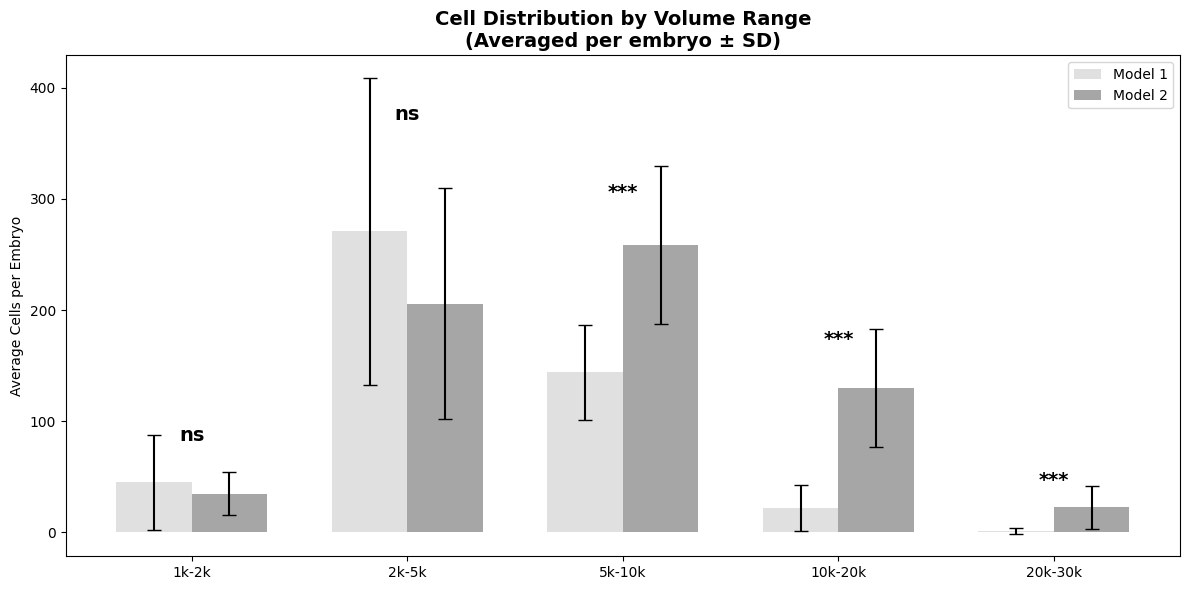

In [1]:

    
    
    
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
plot_volume_bins.py
Load the exported volume data, separate models, compute per‑embryo counts,
and generate Figure 4E style plots.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------------------
# 1. Load the small CSV
# ----------------------------------------------------------------------
csv_path = "/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4E/Fig4E_volume_data.csv"
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} rows from CSV")

# ----------------------------------------------------------------------
# 2. Split by model immediately (to avoid any mixing)
# ----------------------------------------------------------------------
model1_df = df[df['model'] == 'Model_1'].copy()
model2_df = df[df['model'] == 'Model_2'].copy()
print(f"Model_1 cells: {len(model1_df)}, Model_2 cells: {len(model2_df)}")

# ----------------------------------------------------------------------
# 3. Filter volume range (same as original)
# ----------------------------------------------------------------------
volume_lower = 1000
volume_upper = 30000
model1_df = model1_df[(model1_df['volume'] >= volume_lower) & (model1_df['volume'] <= volume_upper)]
model2_df = model2_df[(model2_df['volume'] >= volume_lower) & (model2_df['volume'] <= volume_upper)]
print(f"After volume filtering: Model_1 {len(model1_df)}, Model_2 {len(model2_df)}")

# ----------------------------------------------------------------------
# 4. Define volume bins
# ----------------------------------------------------------------------
ranges = ['Small\n(1k-2k)', 'Medium\n(2k-5k)', 'Large\n(5k-10k)',
          'Very Large\n(10k-20k)', 'Extra Large\n(20k-30k)']
ranges = ['1k-2k', '2k-5k', '5k-10k',
          '10k-20k', '20k-30k']
bins = [1000, 2000, 5000, 10000, 20000, volume_upper]

model1_df['volume_bin'] = pd.cut(model1_df['volume'], bins=bins, labels=ranges)
model2_df['volume_bin'] = pd.cut(model2_df['volume'], bins=bins, labels=ranges)

# ----------------------------------------------------------------------
# 5. Per‑embryo counts (each embryo = Custom cell groups)
#    Now computed separately for each model
# ----------------------------------------------------------------------
def get_embryo_counts(df):
    """Return a DataFrame with embryo IDs as index, bins as columns"""
    counts = (
        df.groupby(['Custom cell groups', 'volume_bin'], observed=False)
        .size()
        .unstack('volume_bin', fill_value=0)
    )
    # Ensure all bins are present (some embryos might have zero in a bin)
    counts = counts.reindex(columns=ranges, fill_value=0)
    return counts

model1_counts = get_embryo_counts(model1_df)
model2_counts = get_embryo_counts(model2_df)

print(f"Number of embryos (Model_1): {len(model1_counts)}")
print(f"Number of embryos (Model_2): {len(model2_counts)}")

# ----------------------------------------------------------------------
# 6. Statistics
# ----------------------------------------------------------------------
model1_means = model1_counts.mean()
model1_sds   = model1_counts.std()
model1_sems  = model1_counts.sem()
model2_means = model2_counts.mean()
model2_sds   = model2_counts.std()
model2_sems  = model2_counts.sem()

# Mann‑Whitney U per bin (two‑sided)
p_values = []
for bin_name in ranges:
    m1_data = model1_counts[bin_name].values
    m2_data = model2_counts[bin_name].values
    _, p = mannwhitneyu(m1_data, m2_data, alternative='two-sided')
    p_values.append(p)

# Bonferroni correction
bonferroni_p = np.minimum(np.array(p_values) * len(ranges), 1.0)

print("\nP‑values (raw):")
for b, p in zip([r.replace('\n',' ') for r in ranges], p_values):
    print(f"  {b}: {p:.4f}")
print("\nBonferroni corrected:")
for b, p in zip([r.replace('\n',' ') for r in ranges], bonferroni_p):
    print(f"  {b}: {p:.4f}")

# ----------------------------------------------------------------------
# 7. Plot with error bars (±SD) and significance stars
# ----------------------------------------------------------------------
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

x = np.arange(len(ranges))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, model1_means, width, yerr=model1_sds, capsize=5,
       label='Model 1', color='#D3D3D3', alpha=0.7, error_kw={'elinewidth': 1.5})
ax.bar(x + width/2, model2_means, width, yerr=model2_sds, capsize=5,
       label='Model 2', color='#808080', alpha=0.7, error_kw={'elinewidth': 1.5})

ax.set_ylabel('Average Cells per Embryo')
ax.set_title('Cell Distribution by Volume Range\n(Averaged per embryo ± SD)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ranges)
ax.legend()

# Add significance stars
for i, p in enumerate(p_values):
    y_max = max(model1_means.iloc[i] + model1_sds.iloc[i],
                model2_means.iloc[i] + model2_sds.iloc[i])
    ax.text(i, y_max * 0.9, sig_stars(p),
            ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4E/per_embryo_volume_bins_sd.png',
            dpi=300, bbox_inches='tight')
plt.show()

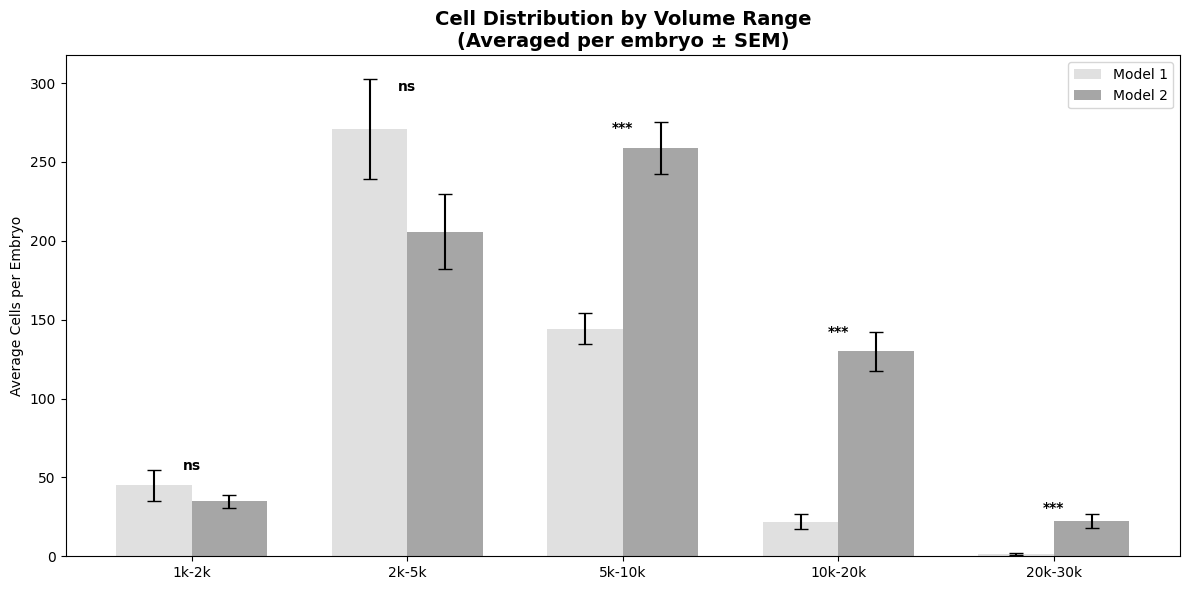


Mean ± SD per embryo:
Volume Bin             Model_1 Mean Model_1 SD Model_2 Mean Model_2 SD
1k-2k                          44.9       42.6         34.8       19.0
2k-5k                         270.8      138.0        205.8      103.9
5k-10k                        144.1       42.8        258.6       71.5
10k-20k                        21.8       20.7        129.9       53.0
20k-30k                         1.4        2.6         22.4       19.5


In [2]:
# ----------------------------------------------------------------------
# 8. Optional: plot with SEM
# ----------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.bar(x - width/2, model1_means, width, yerr=model1_sems, capsize=5,
        label='Model 1', color='#D3D3D3', alpha=0.7, error_kw={'elinewidth': 1.5})
ax2.bar(x + width/2, model2_means, width, yerr=model2_sems, capsize=5,
        label='Model 2', color='#808080', alpha=0.7, error_kw={'elinewidth': 1.5})
ax2.set_ylabel('Average Cells per Embryo')
ax2.set_title('Cell Distribution by Volume Range\n(Averaged per embryo ± SEM)',
              fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(ranges)
ax2.legend()
for i, p in enumerate(p_values):
    y_max = max(model1_means.iloc[i] + model1_sems.iloc[i],
                model2_means.iloc[i] + model2_sems.iloc[i])
    ax2.text(i, y_max * 0.97, sig_stars(p),
             ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4E/per_embryo_volume_bins_sem.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
# 9. Summary table (Mean ± SD) ready for export
# ----------------------------------------------------------------------
print("\nMean ± SD per embryo:")
print(f"{'Volume Bin':<22} {'Model_1 Mean':>12} {'Model_1 SD':>10} {'Model_2 Mean':>12} {'Model_2 SD':>10}")
for b, m1m, m1sd, m2m, m2sd in zip(ranges, model1_means, model1_sds, model2_means, model2_sds):
    print(f"{b.replace(chr(10), ' '):22} {m1m:12.1f} {m1sd:10.1f} {m2m:12.1f} {m2sd:10.1f}")